# AT&T traffic routing: the problem and its candidate routes

Challenge 3, AT&T / QUBIT. Two things happen here: the routing problem is made concrete
on AT&T's real backbone, and **Yen's algorithm** generates the candidate routes that a
QAOA formulation will later choose between.

**Instance:** 10 real PoPs, 5 demands, 2-3 candidate routes each — sized to fill a
28-qubit budget exactly, because every candidate route becomes a qubit.

**Data provenance.** The topology is AT&T's actual North America MPLS backbone from the
[Internet Topology Zoo](http://www.topology-zoo.org/) (Knight et al., IEEE JSAC 2011),
which built it from AT&T's published `Domestic_OC-768_Network.pdf`. Real PoP codes, real
coordinates, real links. Link **delays are derived** from that real geography. Link
**capacities, costs and the traffic matrix are synthesized** by us, since no carrier
publishes those; the methods are documented in `att_real.py`.

Kernel: **Clasiq (venv)**.

In [1]:
import sys, pathlib

# the pipeline modules live next to this notebook, in network_instance/
for candidate in ("network_instance", "att_routing", "."):
    d = pathlib.Path.cwd() / candidate
    if (d / "att_real.py").exists():
        sys.path.insert(0, str(d)); break
else:
    raise RuntimeError("cannot find att_real.py; run this notebook from the repo root")

import matplotlib.pyplot as plt
import pandas as pd

import att_real as A, topologies as T, viz, yen

pd.set_option("display.max_colwidth", 90)
pd.set_option("display.width", 200)

net = A.att_backbone(region="east10")
print(net.headline)
print("validation:", "CLEAN" if not T.validate(net) else T.validate(net))

REAL AT&T MPLS backbone, east10 region: 10 PoPs / 18 links / 5 demands
validation: CLEAN


## 1. The network, on a real map

These are **backbone PoPs**, not cell towers: the fibre sites where AT&T's long-haul
links terminate. Positions are each PoP's true longitude and latitude from the Topology
Zoo record, drawn over real US state boundaries, so this is genuine geography rather
than a layout algorithm's guess.

Left is the whole 25-PoP backbone. Right is the 10-PoP region we work on.

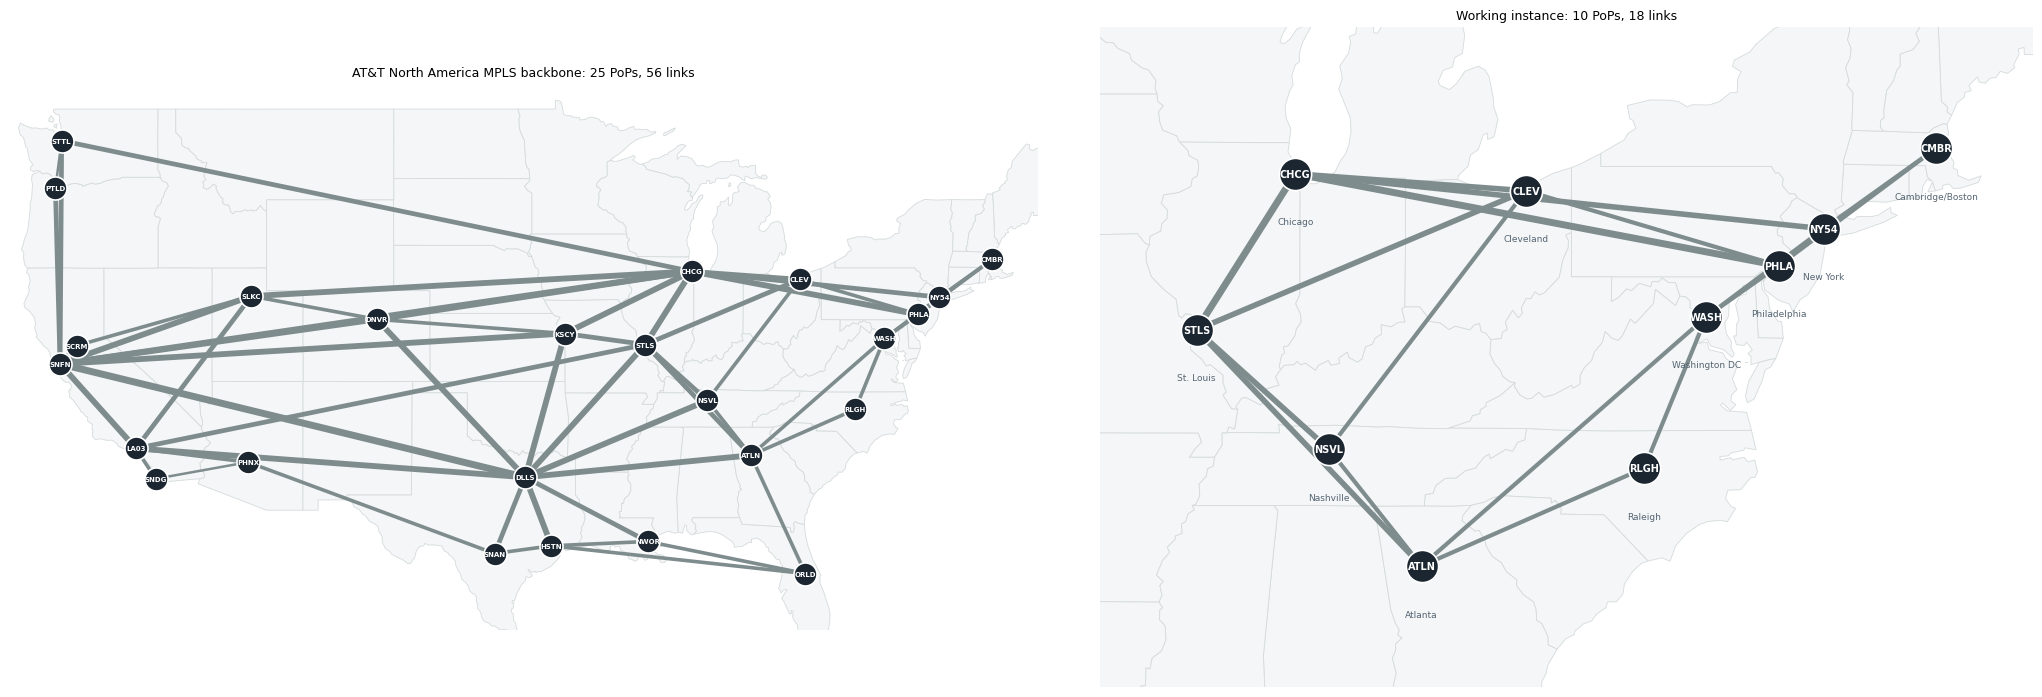

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(21, 7))
viz.draw_map(A.att_backbone(), ax=axes[0],
             title="AT&T North America MPLS backbone: 25 PoPs, 56 links", font_size=5)
viz.draw_map(net, ax=axes[1], annotate=True, font_size=7,
             title=f"Working instance: {net.n_nodes} PoPs, {net.n_links} links")
plt.tight_layout(); plt.show()

### Why it needs fixing

Today every demand independently takes its own shortest path, the way plain OSPF does.
Each decision is locally sensible; together they pile onto the same few links. Red dashed
links are **over capacity** — physically impossible, meaning dropped packets.

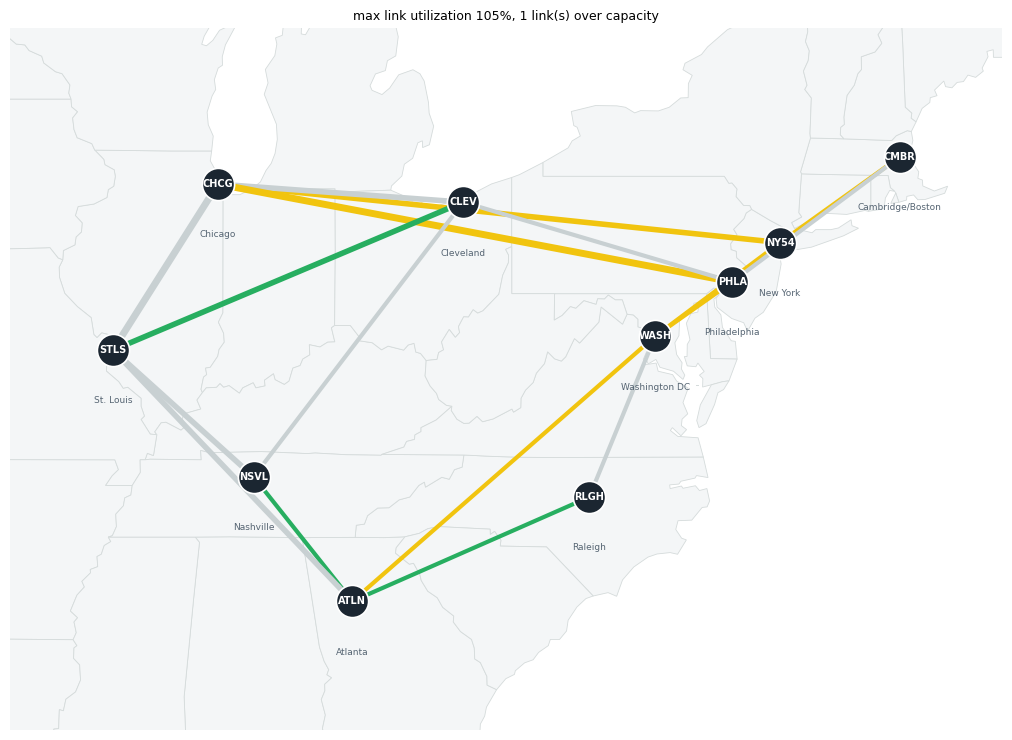

In [3]:
fig, ax = plt.subplots(figsize=(12, 7.5))
viz.draw_map(net, routing=net.current_routing, ax=ax, annotate=True, font_size=7)
plt.tight_layout(); plt.show()

## 2. The traffic

Each demand asks for bandwidth between two PoPs, within a latency bound, at a priority.
The largest gets **1+1 protection**: carried on two link-disjoint paths at once, so a
single fibre cut cannot take it down. That doubles the capacity it consumes.

The four demands are spread so **no city appears twice**. The traffic matrix comes from a
gravity model on metro populations, and left unconstrained New York's metro is heavy
enough to claim half of it, which turns a network problem into a New York problem. Capping
each PoP to one demand spreads the load over 8 of the 10 PoPs instead of 5.

In [4]:
viz.demand_table(net)

,demand,from,to,Gbps,latency<=,priority,protection,paths req.,today's delay,today's opex,today's route
0,T1,NY54,CHCG,84,14ms,high,1+1,2,9ms/9ms,252/336,NY54-CHCG | NY54-PHLA-CHCG
1,T2,PHLA,WASH,56,6ms,medium,none,1,2ms,56,PHLA-WASH
2,T3,CMBR,ATLN,56,18ms,medium,none,1,11ms,224,CMBR-NY54-WASH-ATLN
3,T4,CLEV,STLS,25,11ms,low,none,1,6ms,50,CLEV-STLS
4,T5,RLGH,NSVL,20,12ms,low,none,1,7ms,40,RLGH-ATLN-NSVL


## 3. Yen's algorithm

The optimizer will not search all possible routes. It picks one route per demand from a
small precomputed set, so **the quality of that candidate set caps the quality of any
answer**, no matter how good the solver is. Yen's K-shortest-loopless-paths is what
builds it.

How it works: the first path is just the shortest path. For each subsequent one, walk
along an already-accepted path treating every node as a *spur node*, ban the links that
would retrace an existing path from there, and find the best detour onward. The cheapest
such detour becomes the next path. Implementation is in `yen.py`.

It is verified against networkx's own K-shortest-paths across all 300 PoP pairs of the
full AT&T network under three metrics, 900 comparisons, zero mismatches.

In [5]:
import itertools, networkx as nx

full = A.att_backbone().graph
mismatches = checked = 0
for s, t in itertools.combinations(list(full.nodes()), 2):
    for w in (yen.delay_weight, yen.cost_weight, yen.hop_weight):
        mine = [round(wt, 6) for _, wt in yen.yen_k_shortest(full, s, t, k=5, weight=w)]
        ref = [round(yen._path_weight(full, p, w), 6)
               for p in itertools.islice(nx.shortest_simple_paths(full, s, t, weight=w), 5)]
        checked += 1
        mismatches += (mine != ref)
print(f"{checked} comparisons across all {full.number_of_nodes()} PoPs, {mismatches} mismatches")

900 comparisons across all 25 PoPs, 0 mismatches


## 4. Best 5 routes under each constraint

The brief gives each link three attributes — capacity, delay and operational cost — and
they pull in different directions. So Yen's runs once per metric:

| metric | the constraint it serves |
| --- | --- |
| `delay` | latency bound: minimize end-to-end delay |
| `cost` | operational cost: minimize opex per Gbps |
| `hops` | resource usage: touch the fewest links |
| `spare` | link capacity: prefer links with headroom left. This is the minimum-interference idea from the brief's own reading list — route where you do least damage to everyone else's remaining capacity |

Each cell below shows `route [delay, opex, hops, spare capacity]`, and `(!)` marks a
route that breaks the demand's latency bound.

In [6]:
for d in net.demands:
    print(f"\n{'='*100}\n{d.id}: {A.POP_NAMES[d.src]} -> {A.POP_NAMES[d.dst]}   "
          f"{d.bandwidth}G, <={d.latency_bound}ms, {d.priority} priority, "
          f"{'1+1 protected' if d.needs_backup else 'unprotected'}")
    display(viz.metric_table(net, d, k=5))


T1: New York -> Chicago   84G, <=14ms, high priority, 1+1 protected


,best by delay,best by cost,best by hops,best by spare
#1,"NY54-CHCG [8.6ms, $3, 1h, +36G]","NY54-CHCG [8.6ms, $3, 1h, +36G]","NY54-CHCG [8.6ms, $3, 1h, +36G]","NY54-CHCG [8.6ms, $3, 1h, +36G]"
#2,"NY54-PHLA-CHCG [9.0ms, $4, 2h, -4G]","NY54-PHLA-CLEV-CHCG [9.0ms, $3, 3h, -4G]","NY54-PHLA-CHCG [9.0ms, $4, 2h, -4G]","NY54-CMBR-PHLA-CLEV-CHCG [13.6ms, $4, 4h, +24G]"
#3,"NY54-PHLA-CLEV-CHCG [9.0ms, $3, 3h, -4G]","NY54-PHLA-CHCG [9.0ms, $4, 2h, -4G]","NY54-CMBR-PHLA-CHCG [13.6ms, $5, 3h, +24G]","NY54-CMBR-PHLA-CHCG [13.6ms, $5, 3h, +24G]"
#4,"NY54-WASH-PHLA-CHCG [12.0ms, $5, 3h, +24G]","NY54-CMBR-PHLA-CLEV-CHCG [13.6ms, $4, 4h, +24G]","NY54-PHLA-CLEV-CHCG [9.0ms, $3, 3h, -4G]","NY54-CMBR-PHLA-CLEV-STLS-CHCG [18.9ms, $6, 5h, +24G] (!)"
#5,"NY54-WASH-PHLA-CLEV-CHCG [12.0ms, $4, 4h, +24G]","NY54-WASH-PHLA-CLEV-CHCG [12.0ms, $4, 4h, +24G]","NY54-WASH-PHLA-CHCG [12.0ms, $5, 3h, +24G]","NY54-WASH-RLGH-ATLN-STLS-CHCG [18.3ms, $6, 5h, +24G] (!)"



T2: Philadelphia -> Washington DC   56G, <=6ms, medium priority, unprotected


,best by delay,best by cost,best by hops,best by spare
#1,"PHLA-WASH [1.5ms, $1, 1h, +24G]","PHLA-WASH [1.5ms, $1, 1h, +24G]","PHLA-WASH [1.5ms, $1, 1h, +24G]","PHLA-WASH [1.5ms, $1, 1h, +24G]"
#2,"PHLA-NY54-WASH [3.5ms, $2, 2h, -4G]","PHLA-NY54-WASH [3.5ms, $2, 2h, -4G]","PHLA-NY54-WASH [3.5ms, $2, 2h, -4G]","PHLA-CLEV-STLS-ATLN-RLGH-WASH [22.9ms, $7, 5h, +60G] (!)"
#3,"PHLA-CMBR-NY54-WASH [8.1ms, $3, 3h, +24G] (!)","PHLA-CMBR-NY54-WASH [8.1ms, $3, 3h, +24G] (!)","PHLA-CMBR-NY54-WASH [8.1ms, $3, 3h, +24G] (!)","PHLA-CLEV-NSVL-ATLN-RLGH-WASH [19.5ms, $6, 5h, +60G] (!)"
#4,"PHLA-CLEV-NSVL-ATLN-WASH [18.9ms, $6, 4h, +24G] (!)","PHLA-CLEV-CHCG-NY54-WASH [19.1ms, $6, 4h, +24G] (!)","PHLA-CHCG-NY54-WASH [19.1ms, $7, 3h, +24G] (!)","PHLA-CLEV-CHCG-STLS-ATLN-RLGH-WASH [23.8ms, $7, 6h, +60G] (!)"
#5,"PHLA-CHCG-NY54-WASH [19.1ms, $7, 3h, +24G] (!)","PHLA-CLEV-NSVL-ATLN-WASH [18.9ms, $6, 4h, +24G] (!)","PHLA-CLEV-CHCG-NY54-WASH [19.1ms, $6, 4h, +24G] (!)","PHLA-CLEV-NSVL-STLS-ATLN-RLGH-WASH [25.6ms, $8, 6h, +60G] (!)"



T3: Cambridge/Boston -> Atlanta   56G, <=18ms, medium priority, unprotected


,best by delay,best by cost,best by hops,best by spare
#1,"CMBR-NY54-WASH-ATLN [11.3ms, $4, 3h, +24G]","CMBR-NY54-WASH-ATLN [11.3ms, $4, 3h, +24G]","CMBR-NY54-WASH-ATLN [11.3ms, $4, 3h, +24G]","CMBR-PHLA-CLEV-STLS-ATLN [19.1ms, $6, 4h, +80G] (!)"
#2,"CMBR-PHLA-WASH-ATLN [11.3ms, $4, 3h, +24G]","CMBR-PHLA-WASH-ATLN [11.3ms, $4, 3h, +24G]","CMBR-PHLA-WASH-ATLN [11.3ms, $4, 3h, +24G]","CMBR-PHLA-CLEV-NSVL-ATLN [15.7ms, $5, 4h, +60G]"
#3,"CMBR-NY54-PHLA-WASH-ATLN [11.3ms, $5, 4h, -4G]","CMBR-NY54-WASH-RLGH-ATLN [11.9ms, $4, 4h, +24G]","CMBR-NY54-CHCG-STLS-ATLN [19.6ms, $7, 4h, +24G] (!)","CMBR-PHLA-CLEV-CHCG-STLS-ATLN [20.0ms, $6, 5h, +80G] (!)"
#4,"CMBR-NY54-WASH-RLGH-ATLN [11.9ms, $4, 4h, +24G]","CMBR-PHLA-WASH-RLGH-ATLN [11.9ms, $4, 4h, +24G]","CMBR-NY54-WASH-RLGH-ATLN [11.9ms, $4, 4h, +24G]","CMBR-PHLA-CLEV-NSVL-STLS-ATLN [21.8ms, $7, 5h, +80G] (!)"
#5,"CMBR-PHLA-WASH-RLGH-ATLN [11.9ms, $4, 4h, +24G]","CMBR-NY54-PHLA-WASH-ATLN [11.3ms, $5, 4h, -4G]","CMBR-PHLA-NY54-WASH-ATLN [13.3ms, $5, 4h, -4G]","CMBR-PHLA-CHCG-STLS-ATLN [20.0ms, $7, 4h, +76G] (!)"



T4: Cleveland -> St. Louis   25G, <=11ms, low priority, unprotected


,best by delay,best by cost,best by hops,best by spare
#1,"CLEV-STLS [5.9ms, $2, 1h, +95G]","CLEV-STLS [5.9ms, $2, 1h, +95G]","CLEV-STLS [5.9ms, $2, 1h, +95G]","CLEV-STLS [5.9ms, $2, 1h, +95G]"
#2,"CLEV-CHCG-STLS [6.8ms, $2, 2h, +120G]","CLEV-CHCG-STLS [6.8ms, $2, 2h, +120G]","CLEV-CHCG-STLS [6.8ms, $2, 2h, +120G]","CLEV-CHCG-STLS [6.8ms, $2, 2h, +120G]"
#3,"CLEV-NSVL-STLS [8.6ms, $3, 2h, +80G]","CLEV-NSVL-STLS [8.6ms, $3, 2h, +80G]","CLEV-NSVL-STLS [8.6ms, $3, 2h, +80G]","CLEV-NSVL-STLS [8.6ms, $3, 2h, +80G]"
#4,"CLEV-NSVL-ATLN-STLS [13.7ms, $5, 3h, +60G] (!)","CLEV-PHLA-CHCG-STLS [15.4ms, $5, 3h, +76G] (!)","CLEV-PHLA-CHCG-STLS [15.4ms, $5, 3h, +76G] (!)","CLEV-NSVL-ATLN-STLS [13.7ms, $5, 3h, +60G] (!)"
#5,"CLEV-PHLA-CHCG-STLS [15.4ms, $5, 3h, +76G] (!)","CLEV-NSVL-ATLN-STLS [13.7ms, $5, 3h, +60G] (!)","CLEV-NSVL-ATLN-STLS [13.7ms, $5, 3h, +60G] (!)","CLEV-PHLA-CHCG-STLS [15.4ms, $5, 3h, +76G] (!)"



T5: Raleigh -> Nashville   20G, <=12ms, low priority, unprotected


,best by delay,best by cost,best by hops,best by spare
#1,"RLGH-ATLN-NSVL [6.9ms, $2, 2h, +60G]","RLGH-ATLN-NSVL [6.9ms, $2, 2h, +60G]","RLGH-ATLN-NSVL [6.9ms, $2, 2h, +60G]","RLGH-ATLN-NSVL [6.9ms, $2, 2h, +60G]"
#2,"RLGH-WASH-ATLN-NSVL [11.9ms, $4, 3h, +24G]","RLGH-WASH-ATLN-NSVL [11.9ms, $4, 3h, +24G]","RLGH-WASH-ATLN-NSVL [11.9ms, $4, 3h, +24G]","RLGH-ATLN-STLS-NSVL [13.0ms, $4, 3h, +60G] (!)"
#3,"RLGH-ATLN-STLS-NSVL [13.0ms, $4, 3h, +60G] (!)","RLGH-ATLN-STLS-NSVL [13.0ms, $4, 3h, +60G] (!)","RLGH-ATLN-STLS-NSVL [13.0ms, $4, 3h, +60G] (!)","RLGH-ATLN-STLS-CLEV-NSVL [21.3ms, $7, 4h, +60G] (!)"
#4,"RLGH-WASH-PHLA-CLEV-NSVL [14.1ms, $5, 4h, +24G] (!)","RLGH-WASH-PHLA-CLEV-NSVL [14.1ms, $5, 4h, +24G] (!)","RLGH-WASH-PHLA-CLEV-NSVL [14.1ms, $5, 4h, +24G] (!)","RLGH-ATLN-STLS-CHCG-CLEV-NSVL [22.2ms, $7, 5h, +60G] (!)"
#5,"RLGH-WASH-NY54-PHLA-CLEV-NSVL [16.1ms, $6, 5h, -4G] (!)","RLGH-WASH-ATLN-STLS-NSVL [18.0ms, $6, 4h, +24G] (!)","RLGH-WASH-ATLN-STLS-NSVL [18.0ms, $6, 4h, +24G] (!)","RLGH-WASH-ATLN-NSVL [11.9ms, $4, 3h, +24G]"


**This is the crux of the problem.** Read across any row and the metrics disagree. The
fastest route is routinely one that is already oversubscribed, while the route with real
headroom is slower or breaks the latency bound outright. There is no single "best" route
to look up, which is exactly why this is an optimization and not a shortest-path query.

## 5. Shortlisting the pool to fit the qubit budget

Every candidate kept costs a qubit, so the pooled routes must be shortlisted. Each demand
keeps 2, and the two largest keep 3, which spends the spare qubits where the contention
actually is. The rule is not "keep the fastest" — two near-identical routes down the same
corridor give the optimizer no real decision and waste a qubit. Instead:

- a **1+1 protected** demand gets the best link-disjoint pair, since that is what
  protection means
- everything else gets the fastest route, plus whichever remaining route **shares the
  fewest links** with it, so the alternative genuinely fails over somewhere else

In [7]:
candidates = yen.budgeted_candidate_set(net, k=5, base=2, extra_for=2)

rows = []
for d in net.demands:
    pool = yen.candidate_routes(net, d, k=5)
    rows.append({
        "demand": d.id,
        "Yen pool": len(pool),
        "legal (within latency)": sum(1 for r in pool if r.within_latency),
        "selected": " || ".join(r.label for r in candidates[d.id]),
        "routes kept": len(candidates[d.id]),
    })
pd.DataFrame(rows)

,demand,Yen pool,legal (within latency),selected,routes kept
0,T1,9,7,NY54-CHCG || NY54-PHLA-CHCG || NY54-WASH-PHLA-CLEV-CHCG,3
1,T2,10,2,PHLA-WASH || PHLA-NY54-WASH,2
2,T3,12,7,CMBR-NY54-WASH-ATLN || CMBR-PHLA-WASH-RLGH-ATLN,2
3,T4,5,3,CLEV-STLS || CLEV-CHCG-STLS,2
4,T5,8,2,RLGH-ATLN-NSVL || RLGH-WASH-ATLN-NSVL,2


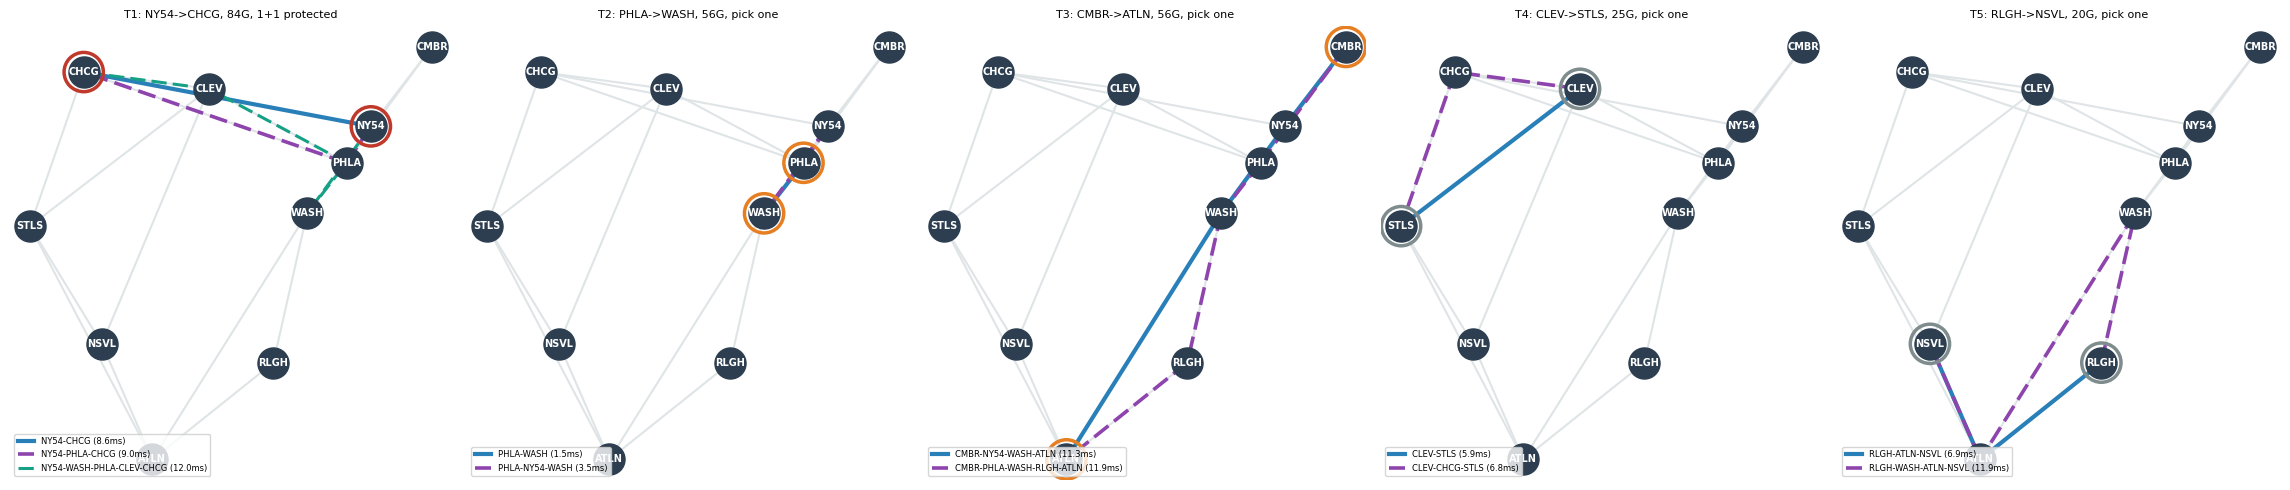

In [8]:
fig, axes = plt.subplots(1, len(net.demands), figsize=(4.6 * len(net.demands), 5))
for ax, d in zip(axes, net.demands):
    viz.draw_routes(net, candidates[d.id], ax=ax,
                    title=f"{d.id}: {d.src}->{d.dst}, {d.bandwidth}G, "
                          f"{'1+1 protected' if d.needs_backup else 'pick one'}")
plt.tight_layout(); plt.show()

Note the two different meanings of "2 routes", both of which the optimizer has to handle:

- **T1 is protected**, so it uses two routes simultaneously and they must be link-disjoint.
  With three candidates it chooses *which disjoint pair*, or rejects.
- **The rest are unprotected**, so exactly one of their routes carries the traffic. Their
  decision is *which route, or reject*.

## 6. The qubit budget

This is why the instance is 10 PoPs and 4 demands. The QUBO needs one qubit per
candidate route, one per admit/reject decision, and a slack register per capacity
constraint sized by the bit-length of that link's capacity.

Two levers keep it small, both exact rather than cosmetic. **Pruning** drops capacity
constraints whose worst case still fits under capacity, since those can never be violated.
**Rescaling** divides every capacity and bandwidth by the same constant, which leaves the
feasible set identical because utilization is a ratio, but shrinks the integers the slack
registers must represent.

The cell that counted these variables built a Pyomo model via `qaoa_model`,
which is not yet committed; it is removed here and restored once that module lands.


## 7. Where this leaves us

The candidate set is built and sized to encode. The open question is still which version
of the problem we solve — offline batch, online arrival, or re-optimization against
today's routing. The brief's "minimize unnecessary route changes against the current
state" points at the third, and `net.current_routing` is the data that makes it
answerable.